# 02 — Agrégation des CSV et analyse ACP

Ce notebook agrège les fichiers CSV de métriques générés dans `csv/`, prépare une table `SubjectID × variables`, puis réalise une ACP.

Les résultats produits sont sauvegardés dans `analysis/` :

- `features_for_pca.csv` : table agrégée utilisée pour l’ACP ;
- `pca_scores.csv` : coordonnées des individus sur les composantes ;
- `pca_loadings.csv` : contributions/loadings des variables ;
- `explained_variance.csv` : variance expliquée par composante.

## 1. Configuration

In [1]:
from pathlib import Path
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def detect_project_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "Chaine",
        Path.cwd() / "chaine_extracted" / "Chaine",
        Path.cwd().parent / "Chaine",
    ]
    for candidate in candidates:
        if (candidate / "csv").exists() and (
            (candidate / "data" / "MainTable.csv").exists() or (candidate / "scripts").exists()
        ):
            return candidate.resolve()
    raise FileNotFoundError(
        "Impossible de détecter automatiquement le dossier Chaine. "
        "Modifiez PROJECT_DIR manuellement dans cette cellule."
    )

# Par défaut, le notebook détecte automatiquement le dossier projet.
# PROJECT_DIR = Path(r"C:/Users/.../Chaine")
PROJECT_DIR = detect_project_dir()

CSV_DIR = PROJECT_DIR / "csv"
ANALYSIS_DIR = PROJECT_DIR / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# Agrégation des métriques.
# "outer" garde tous les étudiants (même présents dans un seul fichier) et impute les valeurs manquantes.
# "inner" garde seulement les étudiants présents dans tous les fichiers.
JOIN_MODE = "outer"  # "outer" ou "inner"

# Imputation des valeurs manquantes avant l'ACP : "median", "mean" ou "drop_rows".
IMPUTATION = "median"

# Nombre minimal de variables non nulles pour conserver un étudiant avant imputation.
MIN_NON_NULL_FEATURES = 2

# Colonnes variables à exclure explicitement de l'ACP, si besoin.
DROP_FEATURES = []

print("Projet :", PROJECT_DIR)
print("Dossier CSV :", CSV_DIR)
print("Dossier analyse :", ANALYSIS_DIR)

Projet : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine
Dossier CSV : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\csv
Dossier analyse : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\analysis


## 2. Chargement et agrégation des fichiers CSV

On charge uniquement les fichiers CSV qui contiennent une colonne `SubjectID`. Les fichiers de suivi comme `run_report.csv` sont ignorés.

In [2]:
if not CSV_DIR.exists():
    raise FileNotFoundError(f"Dossier CSV introuvable : {CSV_DIR}")

csv_paths = sorted(CSV_DIR.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"Aucun fichier CSV trouvé dans : {CSV_DIR}")

tables = []
inventory = []

for path in csv_paths:
    # Fichiers à ignorer.
    if path.name.lower() in {"run_report.csv", "stats.csv"}:
        inventory.append({
            "fichier": path.name,
            "statut": "ignoré",
            "raison": "fichier de rapport/statistiques, pas une métrique SubjectID",
            "lignes": None,
            "colonnes": None,
        })
        continue

    try:
        df = pd.read_csv(path)
    except Exception as exc:
        inventory.append({
            "fichier": path.name,
            "statut": "ignoré",
            "raison": f"lecture impossible : {exc}",
            "lignes": None,
            "colonnes": None,
        })
        continue

    if "SubjectID" not in df.columns:
        inventory.append({
            "fichier": path.name,
            "statut": "ignoré",
            "raison": "pas de colonne SubjectID",
            "lignes": df.shape[0],
            "colonnes": df.shape[1],
        })
        continue

    # Éviter les doublons éventuels par SubjectID dans un même fichier.
    df = df.drop_duplicates(subset=["SubjectID"], keep="first")

    # Préfixe en cas de collision de noms de variables entre fichiers.
    feature_cols = [c for c in df.columns if c != "SubjectID"]
    renamed = {}
    for c in feature_cols:
        if c in {"rows", "columns", "status"}:
            renamed[c] = f"{path.stem}_{c}"
    if renamed:
        df = df.rename(columns=renamed)

    tables.append(df)

    inventory.append({
        "fichier": path.name,
        "statut": "chargé",
        "raison": "",
        "lignes": df.shape[0],
        "colonnes": df.shape[1],
    })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

if not tables:
    raise ValueError("Aucun CSV de métrique exploitable n'a été trouvé.")

features = reduce(lambda left, right: pd.merge(left, right, on="SubjectID", how=JOIN_MODE), tables)
print(f"Table agrégée : {features.shape[0]:,} sujets × {features.shape[1]-1:,} variables")
display(features.head())

,fichier,statut,raison,lignes,colonnes
0,ErrorQuotient_Nowledgeable.csv,chargé,,28,2
1,MaxUnchangedCodeAttempts_Nowledgeable.csv,chargé,,30,2
2,RED_Nowledgeable.csv,chargé,,28,2
3,ScoreProgression_Nowledgeable.csv,chargé,,30,2
4,SessionCount_Nowledgeable.csv,chargé,,30,2
5,TestPassRate_Nowledgeable.csv,chargé,,22,2
6,TotalTestCount_Nowledgeable.csv,chargé,,30,2


Table agrégée : 30 sujets × 7 variables


,SubjectID,ErrorQuotient,MaxUnchangedCodeAttempts,RED,ScoreProgression,SessionCount,TestPassRate,TotalTestCount
0,723,0.000000,1,0.000000,0.000000,1,0.000000,3
1,10032,0.172727,1,0.050000,0.583333,4,0.882353,17
2,10056,0.775120,2,0.608396,0.125000,7,1.000000,2
3,10058,0.500000,3,0.250000,1.000000,5,1.000000,3
4,10119,0.202479,2,0.102273,0.678571,4,0.519231,52


## 3. Nettoyage de la table pour l’ACP

Seules les variables numériques sont conservées. Les variables constantes sont supprimées, car elles n’apportent aucune variance à l’ACP.

In [3]:
features = features.copy()

# Conversion prudente des colonnes en numérique quand c'est possible.
for col in features.columns:
    if col != "SubjectID":
        features[col] = pd.to_numeric(features[col], errors="coerce")

# Exclusions manuelles.
drop_manual = [c for c in DROP_FEATURES if c in features.columns]
if drop_manual:
    features = features.drop(columns=drop_manual)

numeric_cols = [
    c for c in features.columns
    if c != "SubjectID" and pd.api.types.is_numeric_dtype(features[c])
]

X_raw = features[["SubjectID", *numeric_cols]].copy()

# Supprimer les étudiants avec trop peu de variables observées.
non_null_counts = X_raw[numeric_cols].notna().sum(axis=1)
X_raw = X_raw.loc[non_null_counts >= MIN_NON_NULL_FEATURES].reset_index(drop=True)

# Supprimer les variables entièrement vides ou constantes.
usable_cols = []
removed_cols = []
for col in numeric_cols:
    series = X_raw[col]
    if series.notna().sum() == 0:
        removed_cols.append((col, "entièrement vide"))
    elif series.nunique(dropna=True) <= 1:
        removed_cols.append((col, "constante"))
    else:
        usable_cols.append(col)

X_raw = X_raw[["SubjectID", *usable_cols]].copy()

print(f"Sujets conservés : {X_raw.shape[0]:,}")
print(f"Variables conservées : {len(usable_cols):,}")
if removed_cols:
    display(pd.DataFrame(removed_cols, columns=["variable", "raison_suppression"]))

missing_summary = (
    X_raw[usable_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("pct_valeurs_manquantes")
    .reset_index()
    .rename(columns={"index": "variable"})
)
display(missing_summary)

Sujets conservés : 30
Variables conservées : 7


,variable,pct_valeurs_manquantes
0,TestPassRate,26.666667
1,RED,6.666667
2,ErrorQuotient,6.666667
3,MaxUnchangedCodeAttempts,0.000000
4,ScoreProgression,0.000000
5,SessionCount,0.000000
6,TotalTestCount,0.000000


## 4. Imputation, standardisation et ACP

In [4]:
if len(usable_cols) < 2:
    raise ValueError("Il faut au moins deux variables numériques non constantes pour réaliser une ACP.")

X_values = X_raw[usable_cols].copy()

if IMPUTATION == "drop_rows":
    keep_mask = X_values.notna().all(axis=1)
    X_raw_pca = X_raw.loc[keep_mask].reset_index(drop=True)
    X_values = X_raw_pca[usable_cols].copy()
else:
    strategy = {"median": "median", "mean": "mean"}.get(IMPUTATION)
    if strategy is None:
        raise ValueError("IMPUTATION doit valoir 'median', 'mean' ou 'drop_rows'.")
    imputer = SimpleImputer(strategy=strategy)
    X_imputed = imputer.fit_transform(X_values)
    X_values = pd.DataFrame(X_imputed, columns=usable_cols)
    X_raw_pca = X_raw.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

n_components = min(X_scaled.shape[0], X_scaled.shape[1])
pca = PCA(n_components=n_components)
scores = pca.fit_transform(X_scaled)

component_names = [f"PC{i+1}" for i in range(n_components)]

scores_df = pd.DataFrame(scores, columns=component_names)
scores_df.insert(0, "SubjectID", X_raw_pca["SubjectID"].values)

explained_df = pd.DataFrame({
    "component": component_names,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_pct": pca.explained_variance_ratio_ * 100,
    "cumulative_variance_pct": np.cumsum(pca.explained_variance_ratio_) * 100,
    "eigenvalue": pca.explained_variance_,
})

# Loadings : corrélation entre variables standardisées et composantes.
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=usable_cols, columns=component_names).reset_index()
loadings_df = loadings_df.rename(columns={"index": "variable"})

features_for_pca = pd.concat(
    [X_raw_pca[["SubjectID"]].reset_index(drop=True), X_values.reset_index(drop=True)],
    axis=1
)

features_for_pca.to_csv(ANALYSIS_DIR / "features_for_pca.csv", index=False)
scores_df.to_csv(ANALYSIS_DIR / "pca_scores.csv", index=False)
loadings_df.to_csv(ANALYSIS_DIR / "pca_loadings.csv", index=False)
explained_df.to_csv(ANALYSIS_DIR / "explained_variance.csv", index=False)

display(explained_df.head(10))
print("Fichiers sauvegardés dans :", ANALYSIS_DIR)

,component,explained_variance_ratio,explained_variance_pct,cumulative_variance_pct,eigenvalue
0,PC1,0.342983,34.298307,34.298307,2.483671
1,PC2,0.255178,25.517837,59.816144,1.847843
2,PC3,0.136653,13.665321,73.481465,0.989558
3,PC4,0.102661,10.266118,83.747583,0.743409
4,PC5,0.084374,8.437443,92.185026,0.610987
5,PC6,0.061073,6.107340,98.292366,0.442256
6,PC7,0.017076,1.707634,100.000000,0.123656


Fichiers sauvegardés dans : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine\analysis


## 5. Variance expliquée

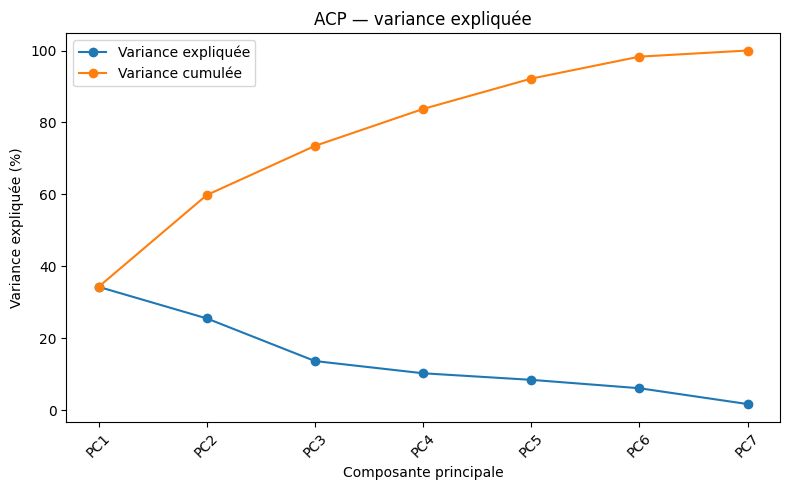

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_df["component"],
    explained_df["explained_variance_pct"],
    marker="o",
    label="Variance expliquée"
)
plt.plot(
    explained_df["component"],
    explained_df["cumulative_variance_pct"],
    marker="o",
    label="Variance cumulée"
)
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée (%)")
plt.title("ACP — variance expliquée")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Projection des individus sur les deux premières composantes

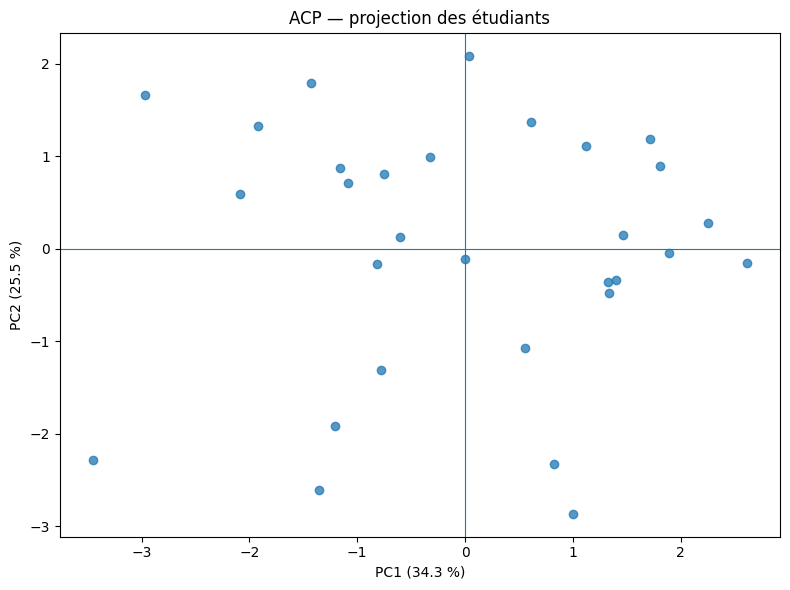

In [6]:
if n_components >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.75)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel(f"PC1 ({explained_df.loc[0, 'explained_variance_pct']:.1f} %)")
    plt.ylabel(f"PC2 ({explained_df.loc[1, 'explained_variance_pct']:.1f} %)")
    plt.title("ACP — projection des étudiants")
    plt.tight_layout()
    plt.show()
else:
    print("Une seule composante disponible : projection PC1/PC2 impossible.")

## 7. Variables les plus liées aux premières composantes

,component,variable,PC1,abs_loading,PC2,PC3,PC4,PC5
0,PC1,ErrorQuotient,0.909589,0.909589,NaN,NaN,NaN,NaN
1,PC1,RED,0.896593,0.896593,NaN,NaN,NaN,NaN
2,PC1,SessionCount,0.651047,0.651047,NaN,NaN,NaN,NaN
3,PC1,TotalTestCount,-0.523745,0.523745,NaN,NaN,NaN,NaN
4,PC1,TestPassRate,0.303048,0.303048,NaN,NaN,NaN,NaN
5,PC1,ScoreProgression,0.228536,0.228536,NaN,NaN,NaN,NaN
6,PC1,MaxUnchangedCodeAttempts,0.101005,0.101005,NaN,NaN,NaN,NaN
7,PC2,ScoreProgression,NaN,0.814446,0.814446,NaN,NaN,NaN
8,PC2,TestPassRate,NaN,0.718342,0.718342,NaN,NaN,NaN
9,PC2,MaxUnchangedCodeAttempts,NaN,0.554242,0.554242,NaN,NaN,NaN


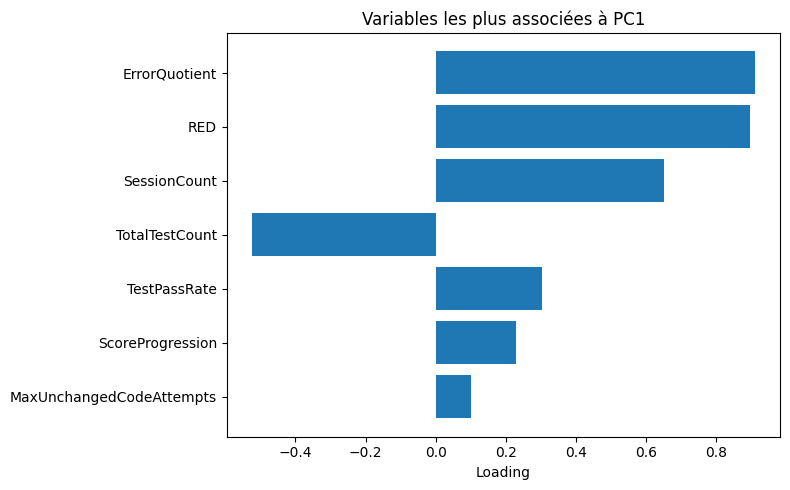

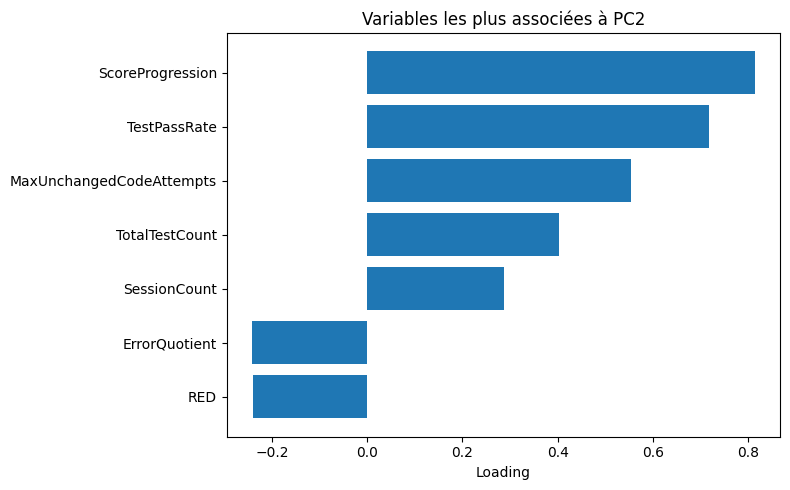

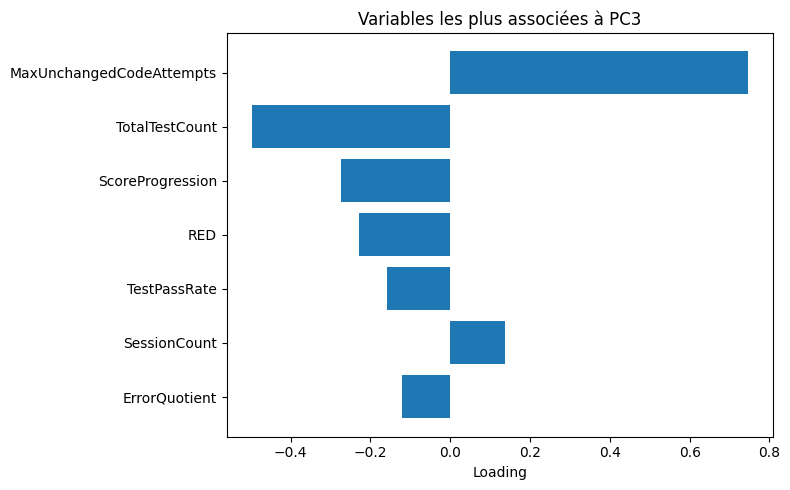

In [7]:
top_rows = []
max_pc_to_show = min(5, n_components)

for pc in component_names[:max_pc_to_show]:
    tmp = loadings_df[["variable", pc]].copy()
    tmp["abs_loading"] = tmp[pc].abs()
    tmp = tmp.sort_values("abs_loading", ascending=False).head(10)
    tmp.insert(0, "component", pc)
    top_rows.append(tmp)

top_loadings_df = pd.concat(top_rows, ignore_index=True)
display(top_loadings_df)

for pc in component_names[:min(3, n_components)]:
    tmp = loadings_df[["variable", pc]].copy()
    tmp = tmp.reindex(tmp[pc].abs().sort_values(ascending=True).index).tail(12)

    plt.figure(figsize=(8, 5))
    plt.barh(tmp["variable"], tmp[pc])
    plt.xlabel("Loading")
    plt.title(f"Variables les plus associées à {pc}")
    plt.tight_layout()
    plt.show()

## 8. Cercle des corrélations / biplot simplifié

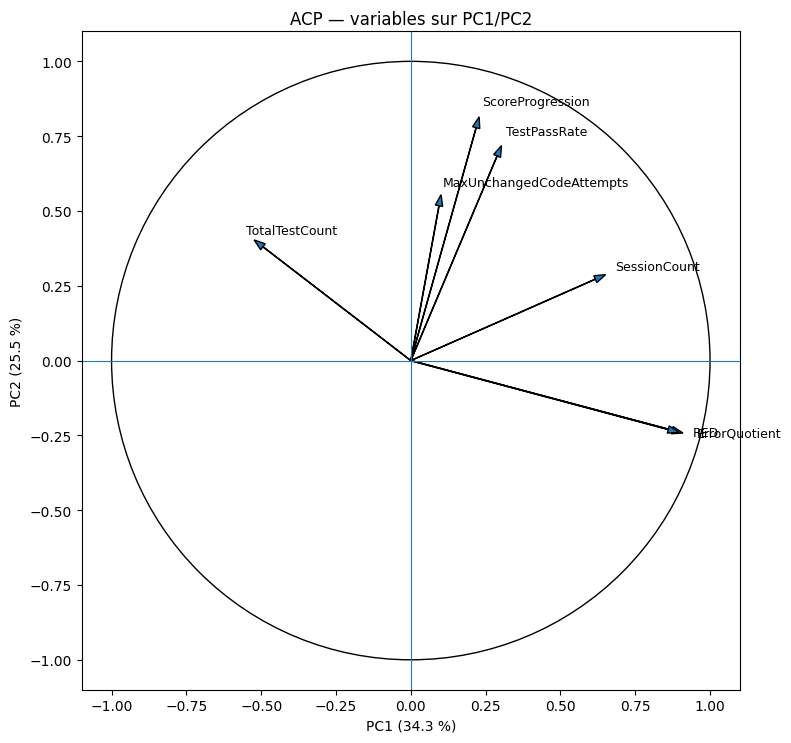

In [8]:
if n_components >= 2:
    coords = loadings_df[["variable", "PC1", "PC2"]].copy()
    coords["norm"] = np.sqrt(coords["PC1"]**2 + coords["PC2"]**2)
    coords_to_plot = coords.sort_values("norm", ascending=False).head(12)

    plt.figure(figsize=(8, 8))
    circle = plt.Circle((0, 0), 1, fill=False)
    ax = plt.gca()
    ax.add_patch(circle)

    for _, row in coords_to_plot.iterrows():
        plt.arrow(0, 0, row["PC1"], row["PC2"], head_width=0.025, length_includes_head=True)
        plt.text(row["PC1"] * 1.05, row["PC2"] * 1.05, row["variable"], fontsize=9)

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(f"PC1 ({explained_df.loc[0, 'explained_variance_pct']:.1f} %)")
    plt.ylabel(f"PC2 ({explained_df.loc[1, 'explained_variance_pct']:.1f} %)")
    plt.title("ACP — variables sur PC1/PC2")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()
else:
    print("Une seule composante disponible : cercle PC1/PC2 impossible.")

## 9. Matrice de corrélation des variables utilisées

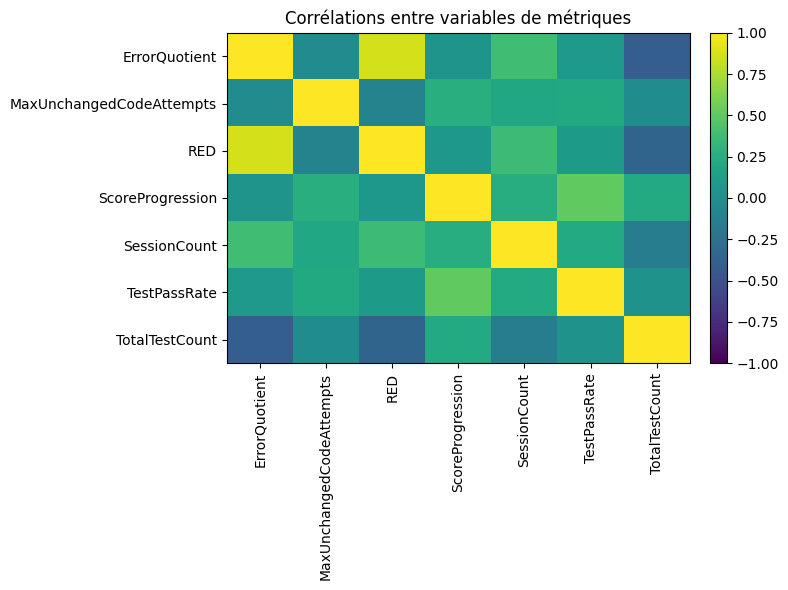

In [9]:
corr = features_for_pca[usable_cols].corr()

plt.figure(figsize=(max(8, 0.55 * len(usable_cols)), max(6, 0.55 * len(usable_cols))))
im = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(usable_cols)), usable_cols, rotation=90)
plt.yticks(range(len(usable_cols)), usable_cols)
plt.title("Corrélations entre variables de métriques")
plt.tight_layout()
plt.show()